# CS 229 - HW3 Extra Credit 1: Time Conditioning Comparison

**Goal.** The base model receives *only* $z_t$ with no timestep input, relying on the fact that
$\|z_t\|$ encodes $t$ (concentration of measure, "The Geometry of Noise", Sahraee-Ardakan et al. 2026).
Here we add an explicit time-conditioned variant (adaLN / FiLM modulation from a sinusoidal time
embedding) and compare it head-to-head with the unconditioned baseline: loss curves, samples, and
denoiser behaviour.

**What to look for.** If the norm of $z_t$ already carries $t$, explicit conditioning should help only
marginally at this scale (D = 3072). We test that prediction empirically.

## Setup (shared with `hw3-1.ipynb`)
Imports, data, model, and the reference flow-matching functions.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%matplotlib inline
import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps') if torch.backends.mps.is_available() else device
print(f'Using device: {device}')
torch.manual_seed(229)

Using device: cuda


In [5]:
data = torch.load('/content/drive/My Drive/hw3_data_dedupe.pt', weights_only=False)
all_images = data['images']   # (N, 3, 32, 32) in [-1, 1]
names = data['names']

# Train/val split (fixed seed, identical to hw3-1)
torch.manual_seed(229)
perm = torch.randperm(len(all_images))
n_val = len(all_images) // 10
images = all_images[perm[n_val:]]
val_images = all_images[perm[:n_val]]
N = len(images)
print(f'Total: {len(all_images)} emoji, shape {all_images.shape}')
print(f'Train: {N}, Val: {len(val_images)}')


def show_grid(imgs, nrow=8, title=None, figsize=None):
    """Display images as a grid. imgs: (N, 3, H, W) in [-1, 1]."""
    imgs = imgs.detach().cpu().clamp(-1, 1)
    grid = make_grid((imgs + 1) / 2, nrow=nrow, padding=1, pad_value=1)
    if figsize is None:
        ncol = min(nrow, len(imgs))
        nrows = (len(imgs) + ncol - 1) // ncol
        figsize = (ncol * 1.5, nrows * 1.5 + 0.5)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    if title:
        plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Total: 1447 emoji, shape torch.Size([1447, 3, 32, 32])
Train: 1303, Val: 144


In [6]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block (no time conditioning)."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


class EmojiViT(nn.Module):
    """Vision Transformer for emoji generation. No time conditioning."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=256, depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(B, self.num_patches, -1)
        return x

    def unpatchify(self, x):
        B = x.shape[0]
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        x = x.reshape(B, h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        x = x.reshape(B, 3, h * p, w * p)
        return x

    def forward(self, x):
        x = self.patchify(x)
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        x = self.head(x)
        x = self.unpatchify(x)
        return x

In [7]:
def add_noise(x, t):
    """z_t = t * x + (1 - t) * eps, eps ~ N(0, I)."""
    noise = torch.randn_like(x)
    return t * x + (1 - t) * noise


def compute_loss(model, x):
    """Weighted x-prediction loss with logit-normal time sampling."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device))
    t = t.reshape(B, 1, 1, 1)
    z_t = add_noise(x, t)
    x_hat = model(z_t)
    return torch.mean(((x_hat - x) / (1 - t)) ** 2)


@torch.no_grad()
def sample(model, num_samples, T=100, device='cpu'):
    """Euler ODE sampler for the x-prediction model."""
    model.eval()
    z = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t_k = k / T
        v = (model(z) - z) / (1 - t_k)
        z = z + dt * v
    return torch.clamp(z, -1, 1)

## A time-conditioned ViT (FiLM / adaLN)
A sinusoidal time embedding feeds an MLP, producing per-block scale/shift/gate modulations applied to LayerNorm outputs.

In [8]:
def timestep_embedding(t, dim, max_period=10000):
    """Sinusoidal embedding of t in [0, 1]. t: (B,) -> (B, dim)."""
    half = dim // 2
    freqs = torch.exp(-math.log(max_period) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None] * 1000.0  # scale up for resolution in [0,1]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb


class TransformerBlockFiLM(nn.Module):
    """Pre-norm Transformer block with adaLN-style time modulation."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)), nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )
        self.mod = nn.Sequential(nn.SiLU(), nn.Linear(dim, 6 * dim))
        nn.init.zeros_(self.mod[1].weight)
        nn.init.zeros_(self.mod[1].bias)

    def forward(self, x, c):
        s1, sc1, g1, s2, sc2, g2 = self.mod(c).chunk(6, dim=-1)
        h = self.norm1(x) * (1 + sc1[:, None]) + s1[:, None]
        h, _ = self.attn(h, h, h)
        x = x + g1[:, None] * h
        h = self.norm2(x) * (1 + sc2[:, None]) + s2[:, None]
        x = x + g2[:, None] * self.mlp(h)
        return x


class EmojiViTFiLM(nn.Module):
    """Time-conditioned ViT. forward(x, t) with t in [0, 1], shape (B,)."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=256, depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.SiLU(), nn.Linear(embed_dim, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlockFiLM(embed_dim, num_heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p).permute(0, 2, 4, 1, 3, 5)
        return x.reshape(B, self.num_patches, -1)

    def unpatchify(self, x):
        B = x.shape[0]
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        x = x.reshape(B, h, w, 3, p, p).permute(0, 3, 1, 4, 2, 5)
        return x.reshape(B, 3, h * p, w * p)

    def forward(self, x, t):
        if not torch.is_tensor(t):
            t = torch.full((x.shape[0],), float(t), device=x.device)
        c = self.time_mlp(timestep_embedding(t, self.embed_dim))
        x = self.patch_embed(self.patchify(x)) + self.pos_embed
        for blk in self.blocks:
            x = blk(x, c)
        return self.unpatchify(self.head(self.norm(x)))

## Time-conditioned loss and sampler
Identical math to the base functions, but the model is given `t`.

In [9]:
def compute_loss_t(model, x):
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device))
    z_t = add_noise(x, t.reshape(B, 1, 1, 1))
    x_hat = model(z_t, t)
    return torch.mean(((x_hat - x) / (1 - t.reshape(B, 1, 1, 1))) ** 2)


@torch.no_grad()
def sample_t(model, num_samples, T=100, device='cpu'):
    model.eval()
    z = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t_k = k / T
        t_vec = torch.full((num_samples,), t_k, device=device)
        v = (model(z, t_vec) - z) / (1 - t_k)
        z = z + dt * v
    return torch.clamp(z, -1, 1)

## Train both models on an identical budget

In [10]:
EPOCHS = 300          # bump to ~500 for best quality
BATCH = 128
LR = 1e-3

def train(model, loss_fn, epochs=EPOCHS, tag=''):
    loader = DataLoader(TensorDataset(images), batch_size=BATCH, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    val = val_images.to(device)
    tr, vl = [], []
    for ep in range(epochs):
        model.train(); run = 0.0
        for (b,) in loader:
            b = b.to(device)
            loss = loss_fn(model, b)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()
        tr.append(run / len(loader))
        model.eval()
        with torch.no_grad():
            vl.append(loss_fn(model, val).item())
        if (ep + 1) % 50 == 0:
            print(f'[{tag}] epoch {ep+1}/{epochs}  train={tr[-1]:.4f}  val={vl[-1]:.4f}')
    return tr, vl

torch.manual_seed(229)
base_model = EmojiViT().to(device)
base_tr, base_vl = train(base_model, compute_loss, tag='no-time')

torch.manual_seed(229)
film_model = EmojiViTFiLM().to(device)
film_tr, film_vl = train(film_model, compute_loss_t, tag='FiLM')
print('params  no-time:', sum(p.numel() for p in base_model.parameters()),
      ' FiLM:', sum(p.numel() for p in film_model.parameters()))

[no-time] epoch 50/300  train=0.2597  val=0.2444
[no-time] epoch 100/300  train=0.2231  val=0.2178
[no-time] epoch 150/300  train=0.2055  val=0.2033
[no-time] epoch 200/300  train=0.1910  val=0.2008
[no-time] epoch 250/300  train=0.1877  val=0.1980
[no-time] epoch 300/300  train=0.1753  val=0.1910
[FiLM] epoch 50/300  train=0.2194  val=0.2081
[FiLM] epoch 100/300  train=0.1922  val=0.1902
[FiLM] epoch 150/300  train=0.1811  val=0.1900
[FiLM] epoch 200/300  train=0.1673  val=0.1863
[FiLM] epoch 250/300  train=0.1617  val=0.1838
[FiLM] epoch 300/300  train=0.1518  val=0.1810
params  no-time: 4841920  FiLM: 7335872


## Compare: loss curves

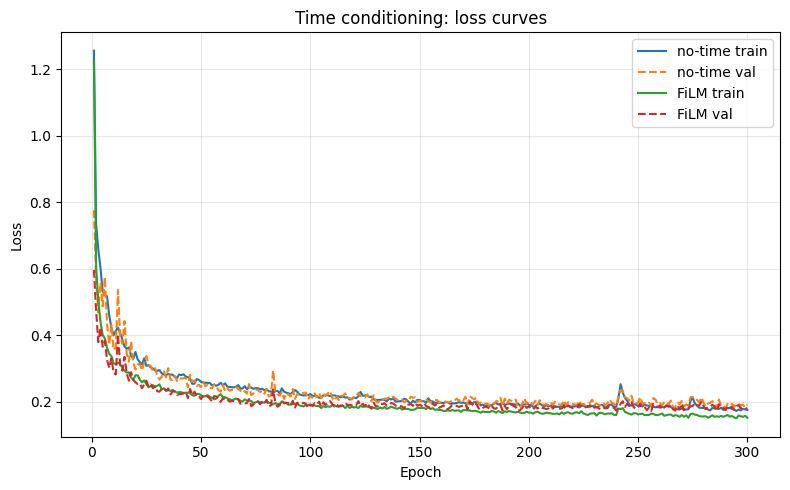

In [11]:
plt.figure(figsize=(8, 5))
ep = range(1, len(base_tr) + 1)
plt.plot(ep, base_tr, label='no-time train')
plt.plot(ep, base_vl, '--', label='no-time val')
plt.plot(ep, film_tr, label='FiLM train')
plt.plot(ep, film_vl, '--', label='FiLM val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Time conditioning: loss curves')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Compare: generated samples (same seed)

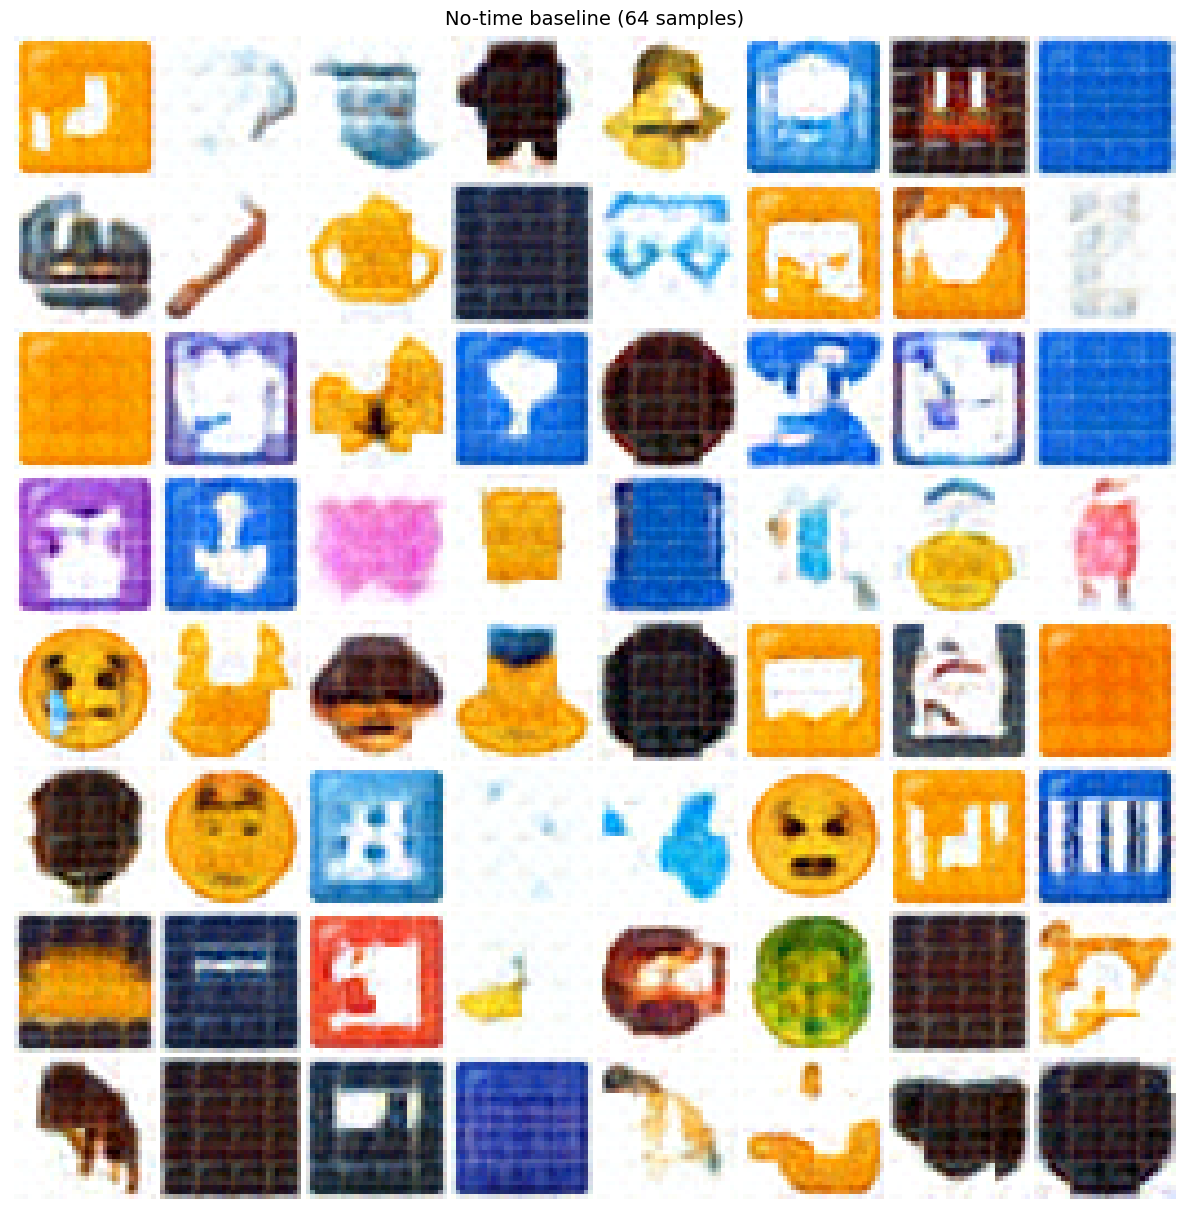

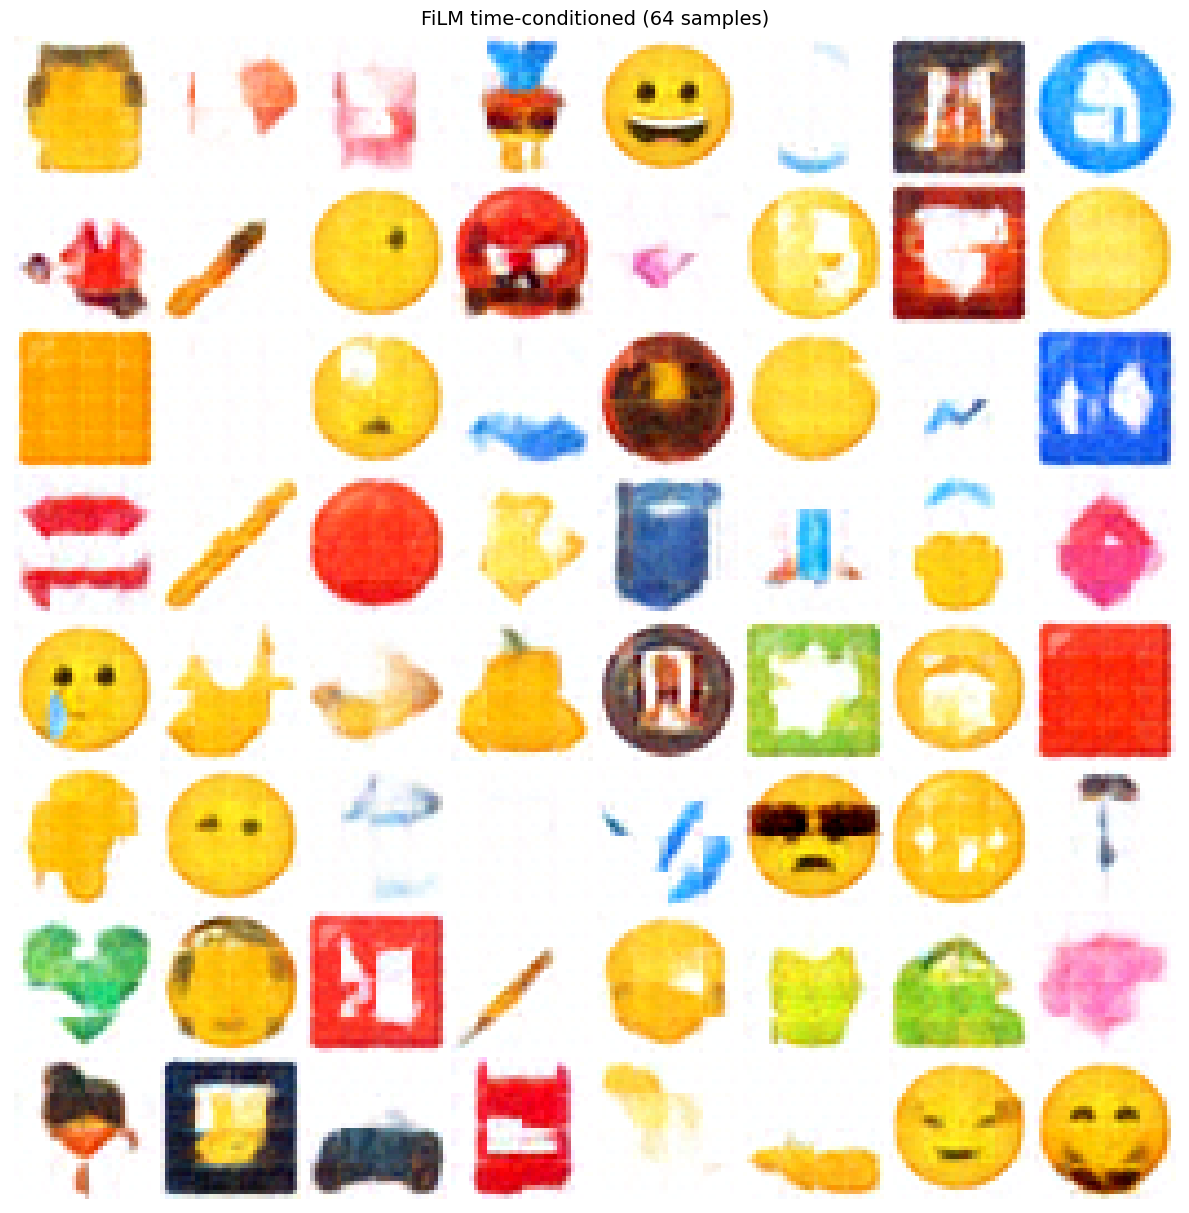

In [12]:
torch.manual_seed(7)
base_samples = sample(base_model, 64, T=100, device=device)
torch.manual_seed(7)
film_samples = sample_t(film_model, 64, T=100, device=device)
show_grid(base_samples, nrow=8, title='No-time baseline (64 samples)')
show_grid(film_samples, nrow=8, title='FiLM time-conditioned (64 samples)')

## Compare: denoiser output at fixed noise levels
Feed the same noisy $z_t$ to each model and compare $\hat{x}$.

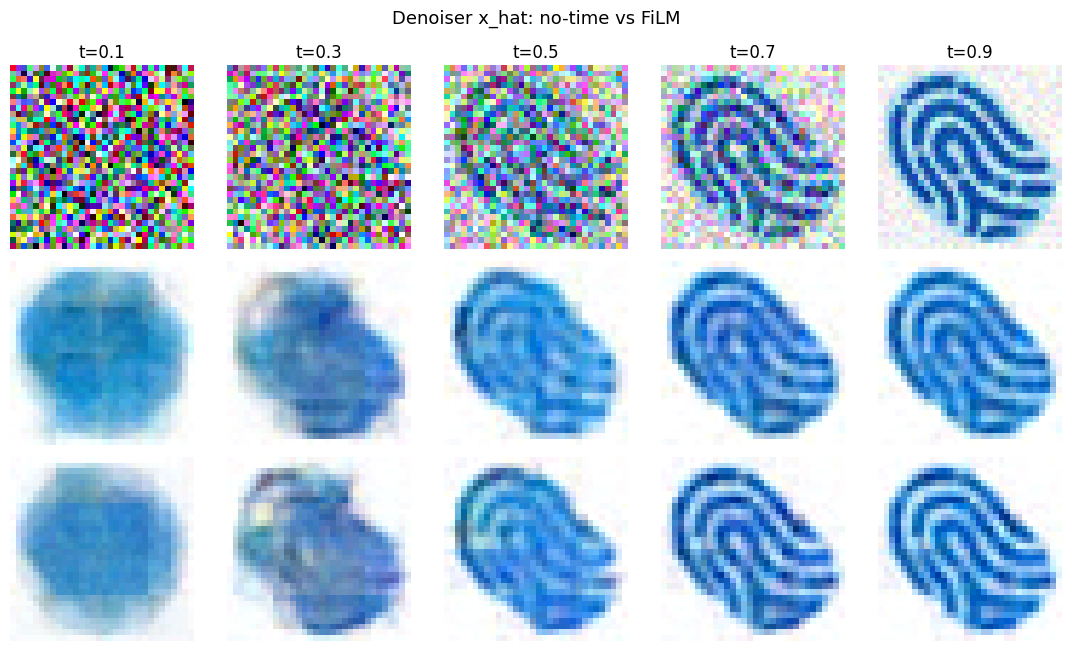

In [13]:
t_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
torch.manual_seed(229)
idx = torch.randint(0, N, (1,)).item()
x = images[idx].to(device)
fig, axes = plt.subplots(3, len(t_levels), figsize=(2.2 * len(t_levels), 6.6))
def to_img(tn):
    return ((tn.detach().cpu().permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
for col, tv in enumerate(t_levels):
    torch.manual_seed(1000 + col)
    z = add_noise(x, tv).unsqueeze(0)
    with torch.no_grad():
        xb = base_model(z)[0]
        xf = film_model(z, torch.tensor([tv], device=device))[0]
    axes[0, col].imshow(to_img(z[0])); axes[0, col].set_title(f't={tv}')
    axes[1, col].imshow(to_img(xb))
    axes[2, col].imshow(to_img(xf))
    for r in range(3):
        axes[r, col].axis('off')
axes[0, 0].set_ylabel('z_t'); axes[1, 0].set_ylabel('no-time'); axes[2, 0].set_ylabel('FiLM')
fig.suptitle('Denoiser x_hat: no-time vs FiLM', fontsize=13)
plt.tight_layout(); plt.show()

## Discussion

- Compare final validation losses and sample sharpness. At $D=3072$, the norm $\|z_t\|$ is tightly
  concentrated around a $t$-dependent value, so the unconditioned model can largely infer $t$ on its own.
- Note where (if anywhere) FiLM helps: typically the hardest mid-range $t$, or marginally crisper samples,
  at the cost of extra parameters and a learned time path.
- Connect to Sahraee-Ardakan et al. (2026): explicit time conditioning is *redundant* in high dimension
  because the geometry of the noised manifold already separates timesteps. Lower-dimensional or
  small-patch regimes would benefit more.

**For the writeup:** report a small table of params and final train/val loss for both models, plus the
sample grids above.